In [7]:
import numpy as np
from collections import OrderedDict
import math
import numpy as np
import pandas as pd
import pymeasure
from time import sleep, time
from matplotlib import pyplot as plt
from matplotlib import style
from datetime import datetime
from pymeasure.instruments.keithley import Keithley2400
from pymeasure.instruments.keithley import Keithley2000
import matplotlib.cm as cm
from glob import glob
import os
import sys

In [8]:
myKeithley = Keithley2400(4)

In [9]:
def get_current_and_confirm():
    questionable = myKeithley.current
    pwrOf2 = math.frexp(questionable)[1]
    while not((pwrOf2 < -20) & (pwrOf2 > -40)):
        questionable = myKeithley.current
        pwrOf2 = math.frexp(questionable)[1]
        sleep(0.5)
    return questionable

def get_source_voltage_and_confirm():
    questionable = myKeithley.source_voltage
    pwrOf2 = math.frexp(questionable)[1]
    while not((pwrOf2 > -1)):
        questionable = myKeithley.source_voltage
        pwrOf2 = math.frexp(questionable)[1]
        sleep(0.5)
    return questionable

print(get_current_and_confirm())
print(get_source_voltage_and_confirm())

3.089419e-11
82.0


In [10]:
# myKeithley.adapter.connection.timeout
def ramp_to_voltage_and_confirm(desiredvoltage,steps = 60,pause=0.2):
    print(f"setting voltage to {desiredvoltage}")
    myKeithley.ramp_to_voltage(desiredvoltage, steps=steps, pause=pause)

    nowishVoltage = np.nan
    # nowishVoltage2 = np.nan

    while nowishVoltage != desiredvoltage:
        try:
            nowishVoltage = get_source_voltage_and_confirm() #myKeithley.source_voltage
            # nowishVoltage = myKeithley.voltage
        except:
            print("it didn't like it")

        print(f"voltage at {nowishVoltage}")
        sleep(2)
    
    print(f"Finalized voltage at {myKeithley.source_voltage}")

In [12]:
ramp_to_voltage_and_confirm(0, steps = 80)

setting voltage to 0
voltage at -82.0
voltage at -82.0
voltage at -82.0
voltage at -82.0
voltage at -82.0
voltage at -82.0
it didn't like it
voltage at -82.0
voltage at 0.0
Finalized voltage at 0.0


In [13]:
print(get_current_and_confirm())
print(get_source_voltage_and_confirm())

1.313622e-11
0.0


In [47]:
def gating_rxx(Vmin, Vmax, Vstep,delay, average,file_path,sample_name,stepsperramp):
    VdataPoints= int(np.absolute(Vmax-Vmin)/Vstep)+1
    voltages = np.linspace(Vmin,Vmax,num=VdataPoints)
    data = OrderedDict()
    data['Voltage'], data['leakage'] = [], []
    filename = file_path+'gating2point'+sample_name+'.csv'
    
    # if np.absolute(Vmin/VdataPoints) > 0.1:
    #     myKeithley.ramp_to_voltage(Vmin, steps = int(np.absolute(Vmin/0.25)), pause=0.3)    
    # # Set the ramp rate to Vmin
    # print ('waiting for initial voltage')
    # while abs(myKeithley.source_voltage - Vmin)>0.5:
    #     sleep(3)
    # print ('Intial voltage set at : ' + str(Vmin))
    # sleep(delay)


    for v in voltages:
        ramp_to_voltage_and_confirm(v,stepsperramp)
        # while abs(myKeithley.source_voltage - i)>0.5:
        #     sleep(1)
        # sleep(delay)
        # print ('Voltage : ' + str(i) + ' checked and stabilized')
        sleep(delay)

        data['Voltage'].append(v)
        current = get_current_and_confirm()
        print('Current : ' + str(current) + 'A')
        data['leakage'].append(current)
        
        plt.plot(data['Voltage'], data['leakage'])
        plt.xlabel('Gate Voltage',fontsize=18)
        plt.ylabel('Leakage',fontsize=18)
        
        print(f'Measurement done for voltage : {v} ')
        datafram = pd.DataFrame({ 'Voltage': np.transpose(data['Voltage']), 'leakage':np.transpose(data['leakage'])})
        #save dataframe to csv file in the same path and file name
        datafram.to_csv(filename,index=False)

    #reset voltage after experiment
    # myKeithley.ramp_to_voltage(0, steps = int(VdataPoints), pause=0.2)


setting voltage to 100.0
voltage at 100.0
Finalized voltage at 100.0
Current : 5.219811e-11A
Measurement done for voltage : 100.0 
setting voltage to 95.0
voltage at 100.0
voltage at 95.0
Finalized voltage at 95.0
Current : 4.575747e-11A
Measurement done for voltage : 95.0 
setting voltage to 90.0
voltage at 95.0
voltage at 90.0
Finalized voltage at 90.0
Current : 4.016625e-11A
Measurement done for voltage : 90.0 
setting voltage to 85.0
voltage at 90.0
voltage at 85.0
Finalized voltage at 85.0
Current : 3.382907e-11A
Measurement done for voltage : 85.0 
setting voltage to 80.0
voltage at 85.0
voltage at 80.0
Finalized voltage at 80.0
Current : 3.03744e-11A
Measurement done for voltage : 80.0 
setting voltage to 75.0
voltage at 80.0
voltage at 75.0
Finalized voltage at 75.0
Current : 2.580361e-11A
Measurement done for voltage : 75.0 
setting voltage to 70.0
voltage at 75.0
voltage at 70.0
Finalized voltage at 70.0
Current : 2.358894e-11A
Measurement done for voltage : 70.0 
setting vol

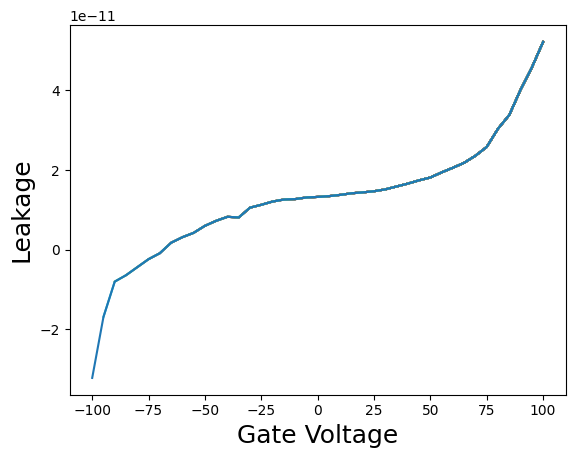

In [48]:
file_path='C:/Users/Ralph Group/Documents/Data/TiffanyFilms/NiFerritePostPaterning/IV/'
sample_name='2450_80V_run15'
average = 1
gating_rxx(100, -100, 5, 10, average,file_path,sample_name,stepsperramp = 30)

In [ ]:
# myKeithley.current

In [ ]:
# df = pd.read_csv('C:/Users/Ralph Group/Documents/Data/TiffanyFilms/NiFerritePostPaterning/IV/gating2pointVoltageVSCurrent.csv')
# plt.plot(df['Voltage'], df['leakage'])

In [119]:
for i in range(1000):
    print(myKeithley.current)
    sleep(1)

-1.054848e-10
-1.143935e-10
-1.238744e-10
-1.173079e-10
-1.137496e-10
-1.118141e-10
-1.185748e-10
-9.082335e-11
-8.386911e-11
-80.0
1.384562e-11
1.394064e-11
1.388081e-11
1.408914e-11
1.373513e-11
1.368375e-11
1.385266e-11
1.400186e-11
1.399905e-11
1.380621e-11
1.37661e-11
1.386463e-11
1.401524e-11
1.370979e-11
1.394627e-11
1.392797e-11
1.385196e-11
1.364505e-11
1.40821e-11
1.405183e-11
1.386604e-11
1.380833e-11
1.387519e-11
1.385407e-11
1.392727e-11
1.375343e-11
1.394205e-11
1.37471e-11
1.374076e-11
1.375484e-11
1.397653e-11
1.374076e-11
1.400891e-11
1.403706e-11
1.373654e-11
1.371472e-11
1.373654e-11
1.39526e-11
1.37471e-11
1.384352e-11
1.399202e-11
1.397935e-11
1.394346e-11
1.392656e-11
1.37485e-11
1.399342e-11
1.377595e-11
1.392868e-11
1.388363e-11
1.378017e-11
1.385478e-11
1.39336e-11
1.370557e-11
1.401172e-11
1.389559e-11
1.381888e-11
1.372246e-11
1.393853e-11
1.390193e-11
1.377384e-11
1.404761e-11
1.407858e-11
1.376328e-11
1.384e-11
1.398709e-11
1.385055e-11
1.378651e-11
1.38322

: 